# Análise de faculdades globais

Esse dataset disponibilizado pelo [Kaggle](https://www.kaggle.com/datasets/sameerk2004/global-college-statistics-dataset) trata-se de um conjunto de dados sintético projetado para fornecer uma visão geral abrangente de dados acadêmicos e demográficos em 50.000 registros. Ele inclui recursos importantes, como IDs de faculdade (por exemplo, "College 1" a "College 100"), países, total de alunos, contagens de alunos do sexo masculino e feminino, CGPA, renda familiar anual e etc.

O objetivo dessa análise é verificar:
- Quais cursos mais buscados em cada país?
- Quais países com melhor CGPA (Cumulative Grade Point Average)?
- Quais cursos que maior empregabilidade?
- Quais fatores influenciam o CGPA de uma faculdade ser alto?

# Tratamento dos dados

## Bibliotecas que serão usadas

In [2]:
import pandas as pd
import numpy as np
import scipy
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import Image, display

## Criando dataset

In [3]:
dataset = pd.read_csv('College Data.csv')
pd.set_option('display.max_columns', None)
dataset

,College ID,Country,Total Students,Male,Female,CGPA,Annual Family Income,Branch,Sports,Research Papers Published,Placement Rate,Faculty Count
0,College 52,UK,27002,2593,11644,10.000000,3574250,Physics,Swimming,39,100.00,655
1,College 93,Switzerland,11913,9392,2521,6.951278,762556,Chemical Engineering,Athletics,31,68.84,256
2,College 15,Japan,15644,5475,4388,9.327922,1795845,Business Administration,Volleyball,37,91.99,555
3,College 72,Singapore,13239,7363,5876,8.681112,1222223,Physics,Tennis,48,97.98,455
4,College 61,Canada,10236,13339,-3103,8.560567,1921133,Biotechnology,Athletics,34,83.56,310
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,College 93,India,14676,10771,3905,8.335598,3151197,Civil Engineering,Cricket,20,65.61,596
49996,College 48,Japan,21908,10682,6820,8.490003,3060006,Physics,Chess,9,99.15,383
49997,College 67,South Africa,17263,11035,6228,5.979781,1519563,Chemical Engineering,Athletics,35,78.28,671
49998,College 54,USA,11371,10233,1138,7.714894,2429788,Mechanical Engineering,Swimming,11,88.46,164


## Tratamento do dataset
Aqui renomearemos colunas, formataremos dados para melhor compreensão e removeremos erros contidos no dataset.

In [4]:
renomear_colunas = ['Faculdade ID', 'Pais', 'Total_Estudantes', 'Estudantes_Masculinos', 'Estudantes_Femininas', 'CGPA',
       'Renda_Familiar_Anual', 'Curso', 'Esportes', 'Pesquisas_Publicadas', 'Taxa_Formados_Empregados', 'Número_Professores']
dataset.columns = renomear_colunas

dataset['CGPA'] = dataset["CGPA"].round(1)
dataset['Taxa_Formados_Empregados'] = pd.to_numeric(dataset['Taxa_Formados_Empregados'], errors='coerce')

dataset['Estudantes_Femininas'] = dataset['Estudantes_Femininas'].abs()

In [5]:
traducao_cursos = {
    'Chemical Engineering': 'Engenharia Química',
    'Physics': 'Física',
    'Electrical Engineering': 'Engenharia Elétrica',
    'Biotechnology': 'Biotecnologia',
    'Economics': 'Economia',
    'Civil Engineering': 'Engenharia Civil',
    'Business Administration': 'Administração de Empresas',
    'Mechanical Engineering': 'Engenharia Mecânica',
    'Computer Science': 'Ciência da Computação',
    'Mathematics': 'Matemática'
}

traducao_esportes = {
    'Swimming': 'Natação',
    'Athletics': 'Atletismo',
    'Volleyball': 'Vôlei',
    'Tennis': 'Tênis',
    'Basketball': 'Basquete',
    'Football': 'Futebol',
    'Badminton': 'Badminton',
    'Cricket': 'Críquete',
    'Chess': 'Xadrez'
}

traducao_paises = {
    'Switzerland': 'Suíça',
    'Singapore': 'Singapura',
    'Japan': 'Japão',
    'China': 'China',
    'Canada': 'Canadá',
    'UK': 'Reino Unido',
    'Australia': 'Austrália',
    'India': 'Índia',
    'South Africa': 'África do Sul',
    'USA': 'Estados Unidos'
}

dataset['Pais'] = dataset['Pais'].replace(traducao_paises)
dataset['Esportes'] = dataset['Esportes'].replace(traducao_esportes)
dataset['Curso'] = dataset['Curso'].replace(traducao_cursos)

## Visualizando o dataset após o tratamento dos dados

In [6]:
dataset

,Faculdade ID,Pais,Total_Estudantes,Estudantes_Masculinos,Estudantes_Femininas,CGPA,Renda_Familiar_Anual,Curso,Esportes,Pesquisas_Publicadas,Taxa_Formados_Empregados,Número_Professores
0,College 52,Reino Unido,27002,2593,11644,10.0,3574250,Física,Natação,39,100.00,655
1,College 93,Suíça,11913,9392,2521,7.0,762556,Engenharia Química,Atletismo,31,68.84,256
2,College 15,Japão,15644,5475,4388,9.3,1795845,Administração de Empresas,Vôlei,37,91.99,555
3,College 72,Singapura,13239,7363,5876,8.7,1222223,Física,Tênis,48,97.98,455
4,College 61,Canadá,10236,13339,3103,8.6,1921133,Biotecnologia,Atletismo,34,83.56,310
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,College 93,Índia,14676,10771,3905,8.3,3151197,Engenharia Civil,Críquete,20,65.61,596
49996,College 48,Japão,21908,10682,6820,8.5,3060006,Física,Xadrez,9,99.15,383
49997,College 67,África do Sul,17263,11035,6228,6.0,1519563,Engenharia Química,Atletismo,35,78.28,671
49998,College 54,Estados Unidos,11371,10233,1138,7.7,2429788,Engenharia Mecânica,Natação,11,88.46,164


### Informações do dataset
Aqui veremos quantas linhas não nulas o dataset possuí e o tipo de dados de cada coluna

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Faculdade ID              50000 non-null  object 
 1   Pais                      50000 non-null  object 
 2   Total_Estudantes          50000 non-null  int64  
 3   Estudantes_Masculinos     50000 non-null  int64  
 4   Estudantes_Femininas      50000 non-null  int64  
 5   CGPA                      50000 non-null  float64
 6   Renda_Familiar_Anual      50000 non-null  int64  
 7   Curso                     50000 non-null  object 
 8   Esportes                  50000 non-null  object 
 9   Pesquisas_Publicadas      50000 non-null  int64  
 10  Taxa_Formados_Empregados  50000 non-null  float64
 11  Número_Professores        50000 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 4.6+ MB


### Descrição dos dados
Aqui temos uma breve descrição estatistica dos dados númericos, como média de valor das colunas, desvio padrão, seus valores mínimos e máximos.

In [8]:
dataset.describe().round(1)

,Total_Estudantes,Estudantes_Masculinos,Estudantes_Femininas,CGPA,Renda_Familiar_Anual,Pesquisas_Publicadas,Taxa_Formados_Empregados,Número_Professores
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
mean,15522.4,7747.1,5721.7,8.7,2611605.6,24.5,82.3,428.9
std,8366.8,4188.4,3824.0,1.1,1387889.0,14.5,11.5,154.7
min,1001.0,500.0,0.0,4.0,200004.0,0.0,60.0,62.0
25%,8272.8,4111.0,2487.0,8.0,1408785.5,12.0,72.4,315.0
50%,15506.5,7756.0,5112.0,8.8,2620902.5,24.0,82.5,428.0
75%,22768.2,11360.0,8504.0,9.7,3811208.5,37.0,92.5,544.0
max,29999.0,14999.0,14999.0,10.0,4999988.0,49.0,100.0,796.0


# Análises Estatísticas
Aqui veremos análises estatísticas referente aos dados do dataset responder nossas perguntas.

## Analisando por estudantes

### Quantidade geral de estudante por país

In [9]:
qtd_estud_pais = dataset.groupby('Pais')['Total_Estudantes'].sum().reset_index()
qtd_estud_pais.sort_values(by='Total_Estudantes',ascending=False)

,Pais,Total_Estudantes
2,China,78785524
8,África do Sul,78611487
7,Suíça,78233472
6,Singapura,77965255
0,Austrália,77368139
3,Estados Unidos,77299951
4,Japão,77166258
1,Canadá,77057301
9,Índia,76900811
5,Reino Unido,76729674


### Quantidade de estudante por gênero

In [10]:
qtd_estud_masc_pais = dataset.groupby('Pais')['Estudantes_Masculinos'].sum().reset_index()
qtd_estud_masc_pais.sort_values(by='Estudantes_Masculinos',ascending=False)

,Pais,Estudantes_Masculinos
8,África do Sul,39302765
2,China,39101368
0,Austrália,39020306
3,Estados Unidos,38865321
7,Suíça,38792394
6,Singapura,38670432
1,Canadá,38596759
4,Japão,38573411
9,Índia,38468236
5,Reino Unido,37962103


In [11]:
qtd_estud_masc_pais = dataset.groupby('Pais')['Estudantes_Femininas'].sum().reset_index()
qtd_estud_masc_pais.sort_values(by='Estudantes_Femininas',ascending=False)

,Pais,Estudantes_Femininas
2,China,29516477
3,Estados Unidos,28842841
0,Austrália,28832090
7,Suíça,28796949
1,Canadá,28733336
6,Singapura,28447927
4,Japão,28399963
8,África do Sul,28344085
9,Índia,28161373
5,Reino Unido,28008096


### Porcentagem de estudantes por gênero

In [12]:
porcent_masc = (dataset.groupby('Pais')['Estudantes_Masculinos'].sum() / dataset.groupby('Pais')['Total_Estudantes'].sum()) * 100
porcent_masc = porcent_masc.round(2).to_frame()
porcent_masc.columns = ['Porcentagem de estudantes do sexo masculino']
porcent_masc

,Porcentagem de estudantes do sexo masculino
Pais,
Austrália,50.43
Canadá,50.09
China,49.63
Estados Unidos,50.28
Japão,49.99
Reino Unido,49.48
Singapura,49.60
Suíça,49.59
África do Sul,50.00


In [13]:
porcent_femen = (dataset.groupby('Pais')['Estudantes_Femininas'].sum() / dataset.groupby('Pais')['Total_Estudantes'].sum()) * 100
porcent_femen = porcent_femen.round(2).to_frame()
porcent_femen.columns = ['Porcentagem de estudantes do sexo feminino']
porcent_femen

,Porcentagem de estudantes do sexo feminino
Pais,
Austrália,37.27
Canadá,37.29
China,37.46
Estados Unidos,37.31
Japão,36.80
Reino Unido,36.50
Singapura,36.49
Suíça,36.81
África do Sul,36.06


Opa, podemos notar que ao somar as porcetagens de estudantes por gênero não conseguimos chegar a 100% da quantidade de estudantes daquele país, vamos averiguar.

#### Hipótese
acredito que há universidades em que a quantidade total de estudantes não é o mesmo valor que o da soma entre a quantidade de estudantes do sexo masculino e feminino, fazendo as universidades terem uma quantidade de estudantes desproporcional em relação à quantidade real.

In [14]:
dataset[(dataset['Estudantes_Femininas'] + dataset['Estudantes_Masculinos']) != dataset['Total_Estudantes']]

,Faculdade ID,Pais,Total_Estudantes,Estudantes_Masculinos,Estudantes_Femininas,CGPA,Renda_Familiar_Anual,Curso,Esportes,Pesquisas_Publicadas,Taxa_Formados_Empregados,Número_Professores
0,College 52,Reino Unido,27002,2593,11644,10.0,3574250,Física,Natação,39,100.00,655
2,College 15,Japão,15644,5475,4388,9.3,1795845,Administração de Empresas,Vôlei,37,91.99,555
4,College 61,Canadá,10236,13339,3103,8.6,1921133,Biotecnologia,Atletismo,34,83.56,310
5,College 21,Estados Unidos,22804,4373,2757,9.1,1885655,Engenharia Química,Basquete,30,85.50,439
6,College 83,Reino Unido,8135,11111,2976,6.9,1191708,Biotecnologia,Vôlei,21,76.13,282
...,...,...,...,...,...,...,...,...,...,...,...,...
49989,College 73,Reino Unido,27394,4720,8287,8.2,1731532,Ciência da Computação,Xadrez,31,84.72,604
49990,College 56,Suíça,9287,6309,912,10.0,4018482,Economia,Críquete,24,75.21,556
49991,College 6,Austrália,22435,10439,10369,7.9,1435003,Engenharia Civil,Basquete,12,73.44,668
49992,College 28,Austrália,15347,5114,6299,10.0,1916342,Ciência da Computação,Críquete,15,85.33,360


Há 36566 universidades em que isso acontece, essa imprecissão nos dados não nos será útil, então ajustaremos o dataset a fim de termos mais precissão em nossos dados.

In [15]:
dataset = dataset.copy()

dataset['Total_Estudantes'] = (dataset['Estudantes_Femininas'] + dataset['Estudantes_Masculinos'])

Agora que corrigimos a quantidade total de estudantes do dataset, vamos iniciar algumas análises para vermos a diferença na quantidade de estudantes após a filtragem:

In [16]:
qtd_estud_pais = dataset.groupby('Pais')['Total_Estudantes'].sum().reset_index()
qtd_estud_pais.sort_values(by='Total_Estudantes',ascending=False)

,Pais,Total_Estudantes
2,China,68617845
0,Austrália,67852396
3,Estados Unidos,67708162
8,África do Sul,67646850
7,Suíça,67589343
1,Canadá,67330095
6,Singapura,67118359
4,Japão,66973374
9,Índia,66629609
5,Reino Unido,65970199


podemos notar a queda drástica no número de estudantes por país, sendo que anteriormente tínhamos 78785524 estudantes na china e agora só temos 68617845, tendo uma perca de cerga média de 10 milhões de estudantes. Agora, vamos averiguar a diferença entre a quantidade de estudantes dos sexos femininos e masculinos:

In [17]:
porcent_femen = (dataset.groupby('Pais')['Estudantes_Femininas'].sum() / dataset.groupby('Pais')['Total_Estudantes'].sum()) * 100
porcent_femen = porcent_femen.round(2).to_frame()
porcent_femen.columns = ['Porcentagem de estudantes do sexo feminino']
porcent_femen

,Porcentagem de estudantes do sexo feminino
Pais,
Austrália,42.49
Canadá,42.68
China,43.02
Estados Unidos,42.60
Japão,42.40
Reino Unido,42.46
Singapura,42.38
Suíça,42.61
África do Sul,41.90


In [18]:
porcent_masc = (dataset.groupby('Pais')['Estudantes_Masculinos'].sum() / dataset.groupby('Pais')['Total_Estudantes'].sum()) * 100
porcent_masc = porcent_masc.round(2).to_frame()
porcent_masc.columns = ['Porcentagem de estudantes do sexo masculino']
porcent_masc

,Porcentagem de estudantes do sexo masculino
Pais,
Austrália,57.51
Canadá,57.32
China,56.98
Estados Unidos,57.40
Japão,57.60
Reino Unido,57.54
Singapura,57.62
Suíça,57.39
África do Sul,58.10


Podemos concluir que realmente se tem muito mais estudantes do sexo masculino do que feminino nas universidades ao redor do globo.

## Analises por universidades

### Avaliação média CGPA das universidades de cada país

In [19]:
media_cgpa_pais = dataset.groupby('Pais')['CGPA'].mean().round(2).reset_index()
media_cgpa_pais = media_cgpa_pais.sort_values(by='CGPA', ascending=False)
media_cgpa_pais

,Pais,CGPA
1,Canadá,8.73
2,China,8.72
9,Índia,8.72
7,Suíça,8.71
6,Singapura,8.71
5,Reino Unido,8.71
4,Japão,8.70
3,Estados Unidos,8.70
0,Austrália,8.69
8,África do Sul,8.68


Podemos notar que as universidades da India, China e Canada possuem as universidades maiores CGPA, ainda que por pouca diferença das demais. Agora vamos averiguar quais paises possuem mais universidades.

### Quantidade de universidades por país

In [20]:
qtd_universid_pais = dataset['Pais'].value_counts().to_frame()
qtd_universid_pais.columns = ['Quantidade de faculdades']
qtd_universid_pais = qtd_universid_pais.sort_values(by='Quantidade de faculdades',ascending=False)
qtd_universid_pais


,Quantidade de faculdades
Pais,
China,5052
África do Sul,5052
Suíça,5025
Austrália,5018
Singapura,5013
Japão,4991
Estados Unidos,4985
Canadá,4974
Reino Unido,4945


É notório que os países com maiores quantidades de faculdades possuem uma média de CGPA inferior aos países com menos faculdades, implicando que quantidade não é igual qualidade de ensino, exceto pela China.

### Quantidade média de estudante por universidade

In [21]:
media_estud_por_univers = (dataset.groupby('Pais')['Total_Estudantes'].sum() / dataset['Pais'].value_counts())
media_estud_por_univers = media_estud_por_univers.round(0).astype(int).to_frame()
media_estud_por_univers.columns = ['Quantidade média de estudante por universidade']
media_estud_por_univers.sort_values(by='Quantidade média de estudante por universidade',ascending=False)

,Quantidade média de estudante por universidade
Pais,
Estados Unidos,13582
China,13582
Canadá,13536
Austrália,13522
Índia,13474
Suíça,13451
Japão,13419
África do Sul,13390
Singapura,13389


Todas as faculdades ao redor do mundo possuem em média cerca de 13 mil estudantes.

### Quantidade média de professores por universidade

In [22]:
media_prof_univers = dataset.groupby('Pais')['Número_Professores'].mean()
media_prof_univers = media_prof_univers.round(0).astype(int).to_frame()
media_prof_univers.columns = ['Quantidade média de professores por faculdade']
media_prof_univers.sort_values(by='Quantidade média de professores por faculdade',ascending=False)

,Quantidade média de professores por faculdade
Pais,
Austrália,430
China,430
Índia,430
Estados Unidos,430
Singapura,430
Suíça,429
Canadá,428
Reino Unido,428
Japão,427


Todas as universidades possuem em média cerca de 430 professores.

### Quantidade média de aluno por turma

In [23]:
media_aluno_turma = (dataset.groupby('Pais')['Total_Estudantes'].sum() / dataset.groupby('Pais')['Número_Professores'].sum())
media_aluno_turma = media_aluno_turma.round(0).to_frame().astype(int)
media_aluno_turma.columns = ['Media de alunos por turma']
media_aluno_turma.sort_values(by='Media de alunos por turma',ascending=False)

,Media de alunos por turma
Pais,
Canadá,32
China,32
Estados Unidos,32
Austrália,31
Japão,31
Reino Unido,31
Singapura,31
Suíça,31
África do Sul,31


Em média todas as faculdades ao redor do mundo possuem turmas de 31 a 32 alunos.

### Quantidade média de pesquisas publicada por faculdades de cada país

In [24]:
media_pesq_facul = dataset.groupby('Pais')['Pesquisas_Publicadas'].mean()
media_pesq_facul = media_pesq_facul.round(0).to_frame().astype(int)
media_pesq_facul.columns = ['Media de pesquisa por faculdade']
media_pesq_facul.sort_values(by='Media de pesquisa por faculdade',ascending=False)

,Media de pesquisa por faculdade
Pais,
Canadá,25
Estados Unidos,25
África do Sul,25
Japão,25
Suíça,25
Austrália,24
Reino Unido,24
China,24
Singapura,24


Em média todas as faculdades do mundo publicam de 24 a 25 pesquisas por ano.

## Análise por Curso

### Quantidade de alunos por curso de cada país

In [25]:
qtd_aluno_curso = (
    dataset.pivot_table(
        index='Pais', 
        columns='Curso', 
        values='Total_Estudantes', 
        aggfunc='mean', 
        fill_value=0
    )
    .round()
    .astype(int)
)

qtd_aluno_curso

Curso,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
Pais,,,,,,,,,,
Austrália,13508,13706,13571,13471,13645,13771,13197,13392,13536,13430
Canadá,13620,12909,13420,13627,13928,13335,13549,13682,13628,13656
China,13861,13544,13282,13153,13662,13325,14071,13485,13875,13658
Estados Unidos,13949,13489,13716,13588,13645,13958,13318,13258,13285,13643
Japão,13348,13371,13159,12996,14145,13210,13498,13563,13375,13441
Reino Unido,13542,13331,13275,13649,13569,12955,13006,13311,13385,13431
Singapura,13311,13435,13124,13182,13502,13446,13662,13646,12972,13629
Suíça,13463,13389,13618,13475,13681,13438,13094,13421,13187,13756
África do Sul,13606,13400,13358,13068,13405,13281,13406,13238,13646,13459


### Qual curso possuir maior média de estudantes em cada país?

In [26]:
curso_columns = qtd_aluno_curso.columns.tolist()
maior_qtd_aluno_curso_pais = qtd_aluno_curso

maior_qtd_aluno_curso_pais['Curso'] = maior_qtd_aluno_curso_pais[curso_columns].idxmax(axis=1)
maior_qtd_aluno_curso_pais['Quantidade média de alunos'] = maior_qtd_aluno_curso_pais[curso_columns].max(axis=1)

maior_qtd_aluno_curso_pais.reset_index(inplace=True)
resultado = maior_qtd_aluno_curso_pais[['Pais', 'Curso', 'Quantidade média de alunos']]
resultado

Curso,Pais,Curso,Quantidade média de alunos
0,Austrália,Engenharia Elétrica,13771
1,Canadá,Engenharia Civil,13928
2,China,Engenharia Mecânica,14071
3,Estados Unidos,Engenharia Elétrica,13958
4,Japão,Engenharia Civil,14145
5,Reino Unido,Economia,13649
6,Singapura,Engenharia Mecânica,13662
7,Suíça,Matemática,13756
8,África do Sul,Física,13646
9,Índia,Biotecnologia,14024


Vemos que os cursos das áreas de exatas possuem maior adesão dos estudantes ao redor do mundo, exceto por economia e biotecnologia.

### Quantidade de Cursos ofertados por país
Aqui veremos quais aréas de conhecimentos mais presentes nas faculdades de cada país

In [27]:
qtd_cursos_pais = (
    dataset.pivot_table(index='Pais', columns='Curso', values='Faculdade ID', aggfunc='count', fill_value=0)
    .reset_index()
)

qtd_cursos_pais

Curso,Pais,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
0,Austrália,494,506,493,465,511,492,501,546,509,501
1,Canadá,503,480,502,481,465,498,485,532,507,521
2,China,488,520,561,508,513,475,442,521,505,519
3,Estados Unidos,478,515,460,500,497,513,499,520,490,513
4,Japão,484,493,455,473,528,518,514,491,509,526
5,Reino Unido,493,488,513,461,467,522,489,476,511,525
6,Singapura,507,481,491,493,489,518,473,521,531,509
7,Suíça,505,512,504,471,529,493,504,527,510,470
8,África do Sul,511,500,513,468,512,495,531,489,498,535
9,Índia,493,485,516,487,487,494,486,509,539,449


#### Qual curso mais ofertado de cada país?

In [28]:
qtd_cursos_pais['Curso'] = qtd_cursos_pais.iloc[:, 1:].idxmax(axis=1)
qtd_cursos_pais['Quantidade de universidades'] = qtd_cursos_pais.iloc[:, 1:-1].max(axis=1)
qtd_cursos_pais[['Pais', 'Curso', 'Quantidade de universidades']]

Curso,Pais,Curso,Quantidade de universidades
0,Austrália,Engenharia Química,546
1,Canadá,Engenharia Química,532
2,China,Ciência da Computação,561
3,Estados Unidos,Engenharia Química,520
4,Japão,Engenharia Civil,528
5,Reino Unido,Matemática,525
6,Singapura,Física,531
7,Suíça,Engenharia Civil,529
8,África do Sul,Matemática,535
9,Índia,Física,539


Podemos notar que os cursos de engenharia e exatas são os que mais possuem faculdades ao redor do mundo, talvez esteja relacionado com alta demanda de estudantes buscando esses cursos.

##### Gráfico

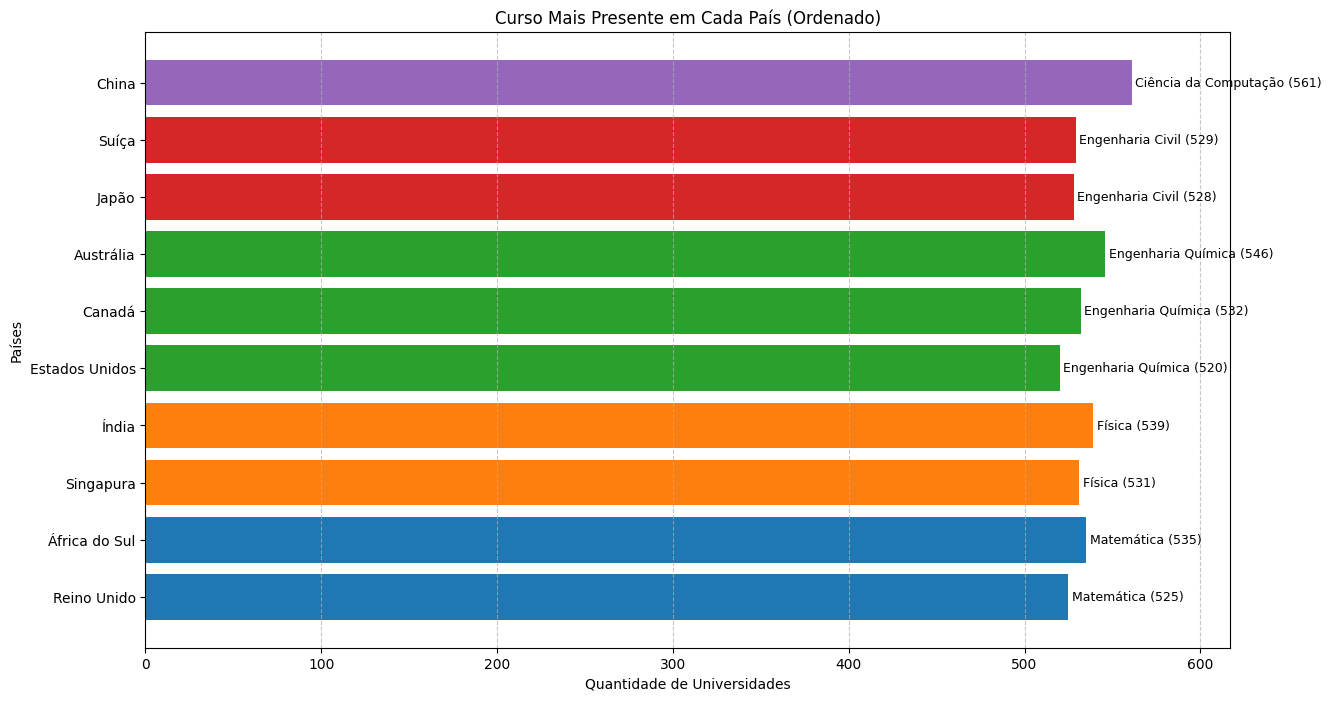

In [29]:
qtd_cursos_pais_order = qtd_cursos_pais.sort_values(by=['Curso', 'Quantidade de universidades'], ascending=[False, True])

cursos_unicos = qtd_cursos_pais_order['Curso'].unique()
cmap = plt.colormaps['tab10']
cores_cursos = {curso: cmap(i) for i, curso in enumerate(cursos_unicos)}

plt.figure(figsize=(14, 8))  
for pais, curso, qtd in zip(qtd_cursos_pais_order['Pais'], qtd_cursos_pais_order['Curso'], qtd_cursos_pais_order['Quantidade de universidades']):
    plt.barh(pais, qtd, color=cores_cursos[curso], height=0.8)  

plt.xlabel('Quantidade de Universidades')
plt.ylabel('Países')
plt.title('Curso Mais Presente em Cada País (Ordenado)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.xlim(0, max(qtd_cursos_pais_order['Quantidade de universidades']) * 1.1)

for pais, curso, qtd in zip(qtd_cursos_pais_order['Pais'], qtd_cursos_pais_order['Curso'], qtd_cursos_pais_order['Quantidade de universidades']):
    plt.text(qtd + 2, pais, f'{curso} ({qtd})', va='center', fontsize=9, color='black')

nome_arquivo = os.path.join('graficos', 'curso-mais-presente-por-pais.jpeg')
plt.savefig(nome_arquivo, format='jpeg', dpi=300, bbox_inches='tight')

plt.show()

### Quantidade média de cursos ofertados globalmente

In [30]:
qtd_cursos = dataset["Curso"].value_counts()
num_paises = dataset["Pais"].nunique()

media_cursos_global = (qtd_cursos / num_paises).round().astype(int)

media_cursos_global = media_cursos_global.to_frame(name='Media global de cursos ofertados')
media_cursos_global = media_cursos_global.sort_values(by='Media global de cursos ofertados', ascending=False)
media_cursos_global


,Media global de cursos ofertados
Curso,
Engenharia Química,513
Física,511
Matemática,507
Engenharia Elétrica,502
Ciência da Computação,501
Engenharia Civil,500
Biotecnologia,498
Administração de Empresas,496
Engenharia Mecânica,492


Como já fora visto anteriormente, os cursos de engenharias e exatas possuem uma média de oferta global muito maior que os cursos das áreas de ciências sociais e ciências biológicas. 

### Avaliação média de CGPA de cada curso globalmente

In [31]:
aval_media_cursos_pais = (
    dataset.pivot_table(index='Pais', columns='Curso', values='CGPA', aggfunc='mean', fill_value=0)
    .round(2).reset_index()
)

aval_media_cursos_pais

Curso,Pais,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
0,Austrália,8.62,8.67,8.72,8.67,8.77,8.64,8.69,8.70,8.74,8.65
1,Canadá,8.64,8.67,8.70,8.66,8.75,8.78,8.77,8.72,8.83,8.74
2,China,8.73,8.69,8.68,8.71,8.70,8.80,8.79,8.74,8.66,8.71
3,Estados Unidos,8.68,8.72,8.71,8.73,8.65,8.66,8.78,8.71,8.65,8.72
4,Japão,8.69,8.67,8.71,8.68,8.76,8.69,8.69,8.68,8.72,8.67
5,Reino Unido,8.72,8.61,8.74,8.69,8.73,8.76,8.67,8.73,8.77,8.66
6,Singapura,8.67,8.71,8.70,8.76,8.72,8.71,8.68,8.70,8.73,8.72
7,Suíça,8.62,8.68,8.78,8.79,8.76,8.72,8.71,8.63,8.62,8.77
8,África do Sul,8.69,8.71,8.63,8.68,8.63,8.70,8.70,8.73,8.70,8.66
9,Índia,8.70,8.72,8.75,8.63,8.76,8.74,8.68,8.74,8.75,8.70


#### Quais cursos possuem maior CGPA em cada país?

In [32]:
maior_aval_media_cursos_pais = aval_media_cursos_pais
maior_aval_media_cursos_pais['Curso'] = aval_media_cursos_pais.iloc[:, 1:].idxmax(axis=1)
maior_aval_media_cursos_pais['CGPA médio'] = aval_media_cursos_pais.iloc[:, 1:-1].max(axis=1)
maior_aval_media_cursos_pais[['Pais', 'Curso', 'CGPA médio']]

Curso,Pais,Curso,CGPA médio
0,Austrália,Engenharia Civil,8.77
1,Canadá,Física,8.83
2,China,Engenharia Elétrica,8.80
3,Estados Unidos,Engenharia Mecânica,8.78
4,Japão,Engenharia Civil,8.76
5,Reino Unido,Física,8.77
6,Singapura,Economia,8.76
7,Suíça,Economia,8.79
8,África do Sul,Engenharia Química,8.73
9,Índia,Engenharia Civil,8.76


Os cursos de engenharias e exatas possuem melhor avaliação na maioria dos países, exceto por Singapura e Suíça que possuem cursos de Economia mais bem avaliados, o que faz sentido, afinal, são países famosos mundialmente por seus bancos.

### Avaliação média global de cada curso

In [33]:
media_cgpa_por_curso = dataset.groupby("Curso")["CGPA"].mean().round(2)
media_cgpa_por_curso = media_cgpa_por_curso.to_frame(name="Média Global CGPA")
media_cgpa_por_curso.sort_values(by="Média Global CGPA", ascending=False)

,Média Global CGPA
Curso,
Engenharia Civil,8.72
Engenharia Elétrica,8.72
Física,8.72
Engenharia Mecânica,8.71
Engenharia Química,8.71
Ciência da Computação,8.71
Economia,8.70
Matemática,8.70
Biotecnologia,8.69


O que foi visto anteriormente se mantém, cursos de exatas e engenharias possuem uma avaliação CGPA maior que os demais cursos.

### Tamanho médio de turma por curso

In [34]:
qtd_prof_curso = dataset.pivot_table(values="Número_Professores", index="Pais", columns="Curso", aggfunc="mean")
qtd_aluno_curso = dataset.pivot_table(values="Total_Estudantes", index="Pais", columns="Curso", aggfunc="mean")
qtd_media_aluno_turma_pais = (qtd_aluno_curso / qtd_prof_curso).round().astype(int)
qtd_media_aluno_turma_pais

Curso,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
Pais,,,,,,,,,,
Austrália,31,32,32,32,32,32,31,31,31,31
Canadá,33,29,32,31,32,31,32,32,32,33
China,33,32,31,30,32,31,32,31,32,32
Estados Unidos,33,31,31,32,32,33,31,31,31,32
Japão,31,32,30,31,33,32,31,31,31,32
Reino Unido,31,31,30,32,31,30,31,31,32,31
Singapura,31,31,31,30,31,31,31,32,30,32
Suíça,31,31,32,31,31,32,30,31,31,32
África do Sul,33,31,31,31,32,31,31,31,32,31


O tamanho das turmas não variam muito, mantendo uma média de 30 alunos por turma de cada curso globalmente, com um pequeno desvio padrão.

### Media de pesquisas realizadas por curso

In [35]:
qtd_pesquisas_curso = dataset.pivot_table(values="Pesquisas_Publicadas", index="Pais", columns="Curso", aggfunc="mean")
qtd_pesquisas_curso = qtd_pesquisas_curso.round().astype(int)
qtd_pesquisas_curso.fillna(0, inplace=True)
qtd_pesquisas_curso

Curso,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
Pais,,,,,,,,,,
Austrália,24,24,23,24,24,24,24,24,25,24
Canadá,24,24,24,24,24,24,26,24,25,25
China,25,25,24,24,24,24,23,26,25,24
Estados Unidos,24,25,25,25,24,24,25,24,25,25
Japão,24,26,25,24,25,25,25,25,24,24
Reino Unido,25,24,24,25,25,25,24,24,25,25
Singapura,24,23,24,23,26,25,24,25,25,25
Suíça,25,25,24,24,25,25,25,24,25,24
África do Sul,23,24,24,25,24,26,25,25,25,24


Também não varia muito, mantendo uma constância média de 24 pesquisas publicada por curso globlamente, com um pequeno desvio padrão.

### Qual a porcentagem de empregabilidade de cada curso por país

In [36]:
porcent_empreg_curso = dataset.pivot_table(
    values="Taxa_Formados_Empregados", 
    index="Pais", 
    columns="Curso", 
    aggfunc="mean", 
    fill_value=0
)

porcent_empreg_curso = porcent_empreg_curso.round(2)
porcent_empreg_curso = porcent_empreg_curso.apply(pd.to_numeric, errors='coerce')
porcent_empreg_curso.fillna(0, inplace=True)
porcent_empreg_curso

Curso,Administração de Empresas,Biotecnologia,Ciência da Computação,Economia,Engenharia Civil,Engenharia Elétrica,Engenharia Mecânica,Engenharia Química,Física,Matemática
Pais,,,,,,,,,,
Austrália,81.95,83.02,82.23,82.45,81.85,82.75,82.37,82.22,82.35,81.26
Canadá,82.14,82.99,82.29,81.38,82.30,82.63,83.08,83.36,81.94,81.78
China,81.29,82.13,82.39,83.11,82.34,82.82,81.10,82.86,82.72,82.15
Estados Unidos,82.10,82.89,82.74,83.06,81.79,81.93,81.80,81.70,82.43,82.19
Japão,81.23,82.48,81.56,81.61,82.19,82.51,82.58,83.50,82.55,82.63
Reino Unido,82.27,83.72,82.83,81.81,82.33,82.16,82.18,82.86,80.91,82.70
Singapura,82.71,82.24,82.19,81.90,82.56,81.97,82.08,82.03,82.20,82.87
Suíça,82.90,82.27,83.61,82.40,81.92,83.13,82.53,83.27,83.01,82.16
África do Sul,82.31,82.44,82.74,82.30,82.92,82.26,82.56,81.79,81.83,82.62


### Qual o curso com maior empregabilidade de cada país?

In [37]:
numeric_cols = porcent_empreg_curso.select_dtypes(include=['number']).columns

maior_porcent_empreg_curso_pais = porcent_empreg_curso

maior_porcent_empreg_curso_pais["Curso"] = maior_porcent_empreg_curso_pais[numeric_cols].idxmax(axis=1)
maior_porcent_empreg_curso_pais["Empregabilidade (%)"] = maior_porcent_empreg_curso_pais[numeric_cols].max(axis=1)

maior_porcent_empreg_curso_pais.reset_index(inplace=True)

maior_porcent_empreg_curso_pais = maior_porcent_empreg_curso_pais[['Pais', 'Curso', 'Empregabilidade (%)']]
maior_porcent_empreg_curso_pais

Curso,Pais,Curso,Empregabilidade (%)
0,Austrália,Biotecnologia,83.02
1,Canadá,Engenharia Química,83.36
2,China,Economia,83.11
3,Estados Unidos,Economia,83.06
4,Japão,Engenharia Química,83.50
5,Reino Unido,Biotecnologia,83.72
6,Singapura,Matemática,82.87
7,Suíça,Ciência da Computação,83.61
8,África do Sul,Engenharia Civil,82.92
9,Índia,Engenharia Civil,82.94


São bem diversos os cursos com maior empregabilidade de cada país, mostrando quais cursos o mercado de trabalho cada país valoriza mais.

### Quais cursos possuem maior empregabilidade no geral?

In [38]:
empreg_cursos_global = dataset.groupby('Curso')['Taxa_Formados_Empregados'].mean()
empreg_cursos_global = empreg_cursos_global.round(2).to_frame().sort_values(by='Taxa_Formados_Empregados',ascending=False)
empreg_cursos_global

,Taxa_Formados_Empregados
Curso,
Biotecnologia,82.62
Engenharia Química,82.52
Ciência da Computação,82.50
Engenharia Elétrica,82.34
Engenharia Civil,82.31
Matemática,82.29
Engenharia Mecânica,82.25
Física,82.21
Economia,82.18


Os cursos com maior média de empregabilidade são Biotecnologia, Engenharia Química e Ciências da Computação, mas apenas com uma diferença de alguns décimos dos demais cursos.

### Adicionando áreas de conhecimento ao dataset
Afim de um entendimento melhor, vamos categorizar os cursos por areas de conhecimento

In [39]:
dataset = dataset.copy()

dataset.loc[:, 'Area'] = dataset['Curso'].apply(lambda x: 
    'Engenharia' if x in ['Engenharia Química', 'Engenharia Elétrica', 
                           'Engenharia Civil', 'Engenharia Mecânica'] else
    'Ciências Exatas' if x in ['Física', 'Matemática', 'Ciência da Computação'] else
    'Ciências Sociais' if x in ['Economia', 'Administração de Empresas'] else
    'Ciências Biológicas' if x in ['Biotecnologia'] else
    'Outras')

##### Quantidade de áreas de conhecimento presente nas universidades de cada país

In [40]:
qtd_area_conhec_pais = (
    dataset.pivot_table(index='Pais', columns='Area', values='Curso', aggfunc='count', fill_value=0)
    .reset_index()
)

qtd_area_conhec_pais

Area,Pais,Ciências Biológicas,Ciências Exatas,Ciências Sociais,Engenharia
0,Austrália,506,1503,959,2050
1,Canadá,480,1530,984,1980
2,China,520,1585,996,1951
3,Estados Unidos,515,1463,978,2029
4,Japão,493,1490,957,2051
5,Reino Unido,488,1549,954,1954
6,Singapura,481,1531,1000,2001
7,Suíça,512,1484,976,2053
8,África do Sul,500,1546,979,2027
9,Índia,485,1504,980,1976


podemos notar que cursos de exatas e engenharias domimam maior parte das faculdades dos países.

#### Gráfico

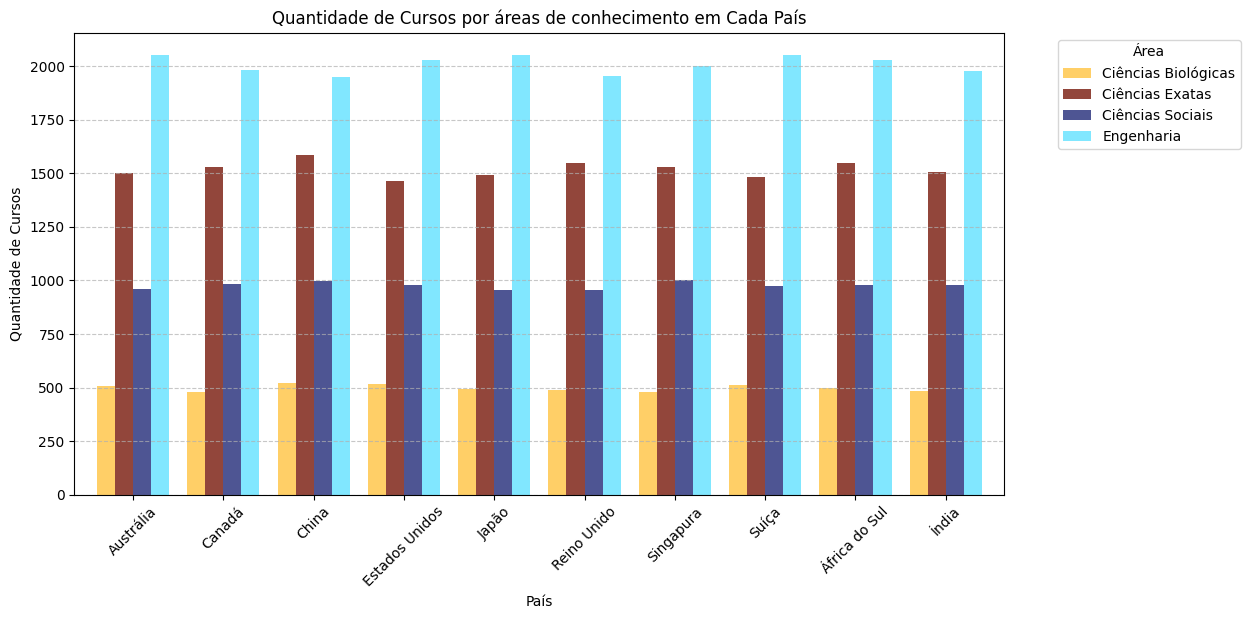

In [41]:
qtd_area_conhec_pais.set_index('Pais').plot(kind='bar', figsize=(12, 6), colormap='managua', width=0.8)

plt.xlabel('País')
plt.ylabel('Quantidade de Cursos')
plt.title('Quantidade de Cursos por áreas de conhecimento em Cada País')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Área', bbox_to_anchor=(1.05, 1), loc='upper left')

nome_arquivo = os.path.join('graficos', 'quantidade-cursos-por-area-conhecimento-pais.jpeg')
plt.savefig(nome_arquivo, format='jpeg', dpi=300, bbox_inches='tight')

plt.show()


# Analise de correlação

Aqui investigaremos quais colunas se correlacionam com a coluna CGPA, a fim de verificar quais fatores influenciam na avaiação CGPA de uma faculdade.

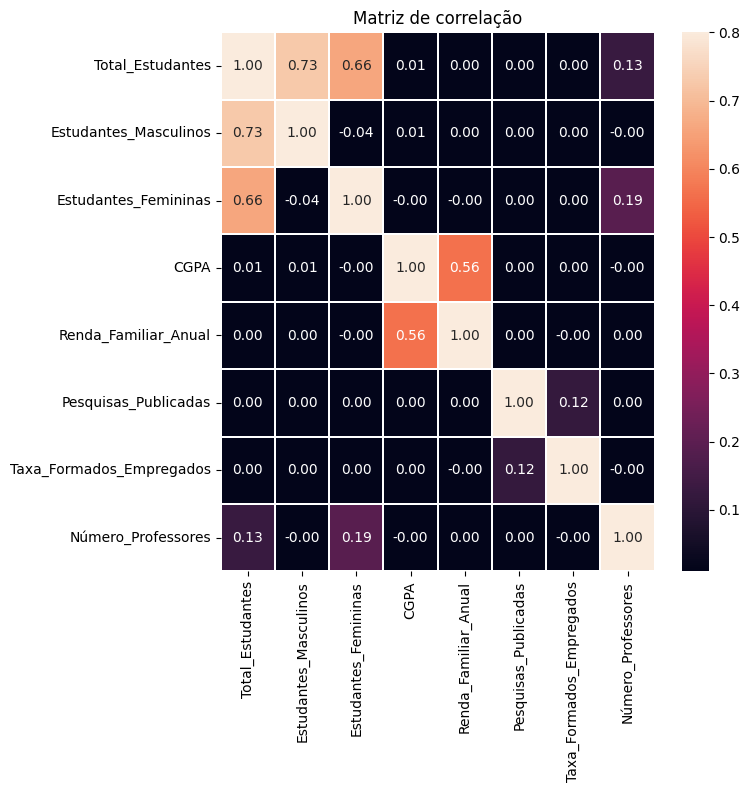

In [42]:
correlacao = dataset.fillna(0).corr(numeric_only=True)
correlacao_formatada = correlacao.map(lambda x: '{:.2f}'.format(x))

plt.figure(figsize=(7,7))
sns.heatmap(correlacao, annot=correlacao_formatada, fmt='', vmin=0.01, vmax=0.8, linewidths=0.1)
plt.title('Matriz de correlação')
plt.show()

O gráfico indica que apenas a coluna de renda média dos estudantes pode possuir correlação com a avaliação CGPA de uma faculdade, então investigaremos se as colunas realmente possuem alguma relação.

## Regressão Linear

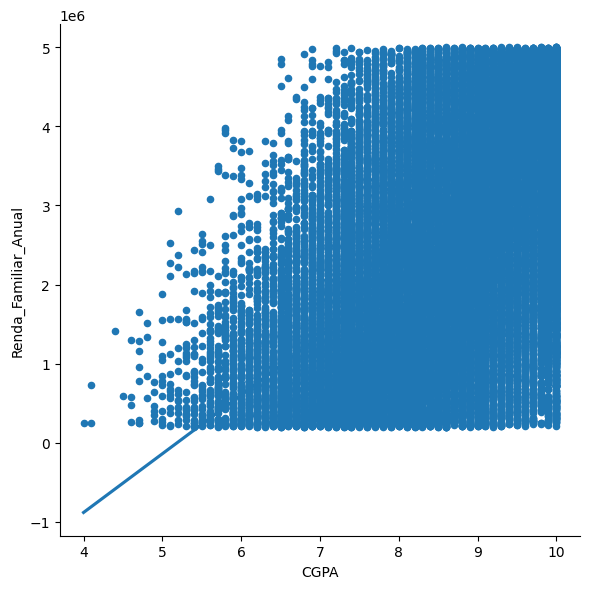

In [43]:
sns.lmplot(
    data=dataset, x="CGPA", y="Renda_Familiar_Anual",
    palette="muted", ci=None, height=6, scatter_kws={"s": 20, "alpha": 1}
)

É perceptível que os dados estão dispersos, entretando, conforme a renda familiar anual média aumenta, as faculdades tendem a deixar de ter notas CGPA inferiores a 6, indicando que á de fato uma relação linear entre as duas colunas. Adiante faremos mais algumas medições para verificar qual o grau de correlação entre as variáveis.

## Medindo o grau de correlação

In [44]:
pd.Series({
    'pearson': dataset.CGPA.corr(dataset.Renda_Familiar_Anual, method='pearson'),
    'spearman': dataset.CGPA.corr(dataset.Renda_Familiar_Anual, method='spearman'),
    'kendall': dataset.CGPA.corr(dataset.Renda_Familiar_Anual, method='kendall')
}, name='correlacao').to_frame().round(2)



,correlacao
pearson,0.56
spearman,0.57
kendall,0.41


As três correlações mostram uma relação positiva entre CGPA e Renda Familiar:

- Pearson (0.56) → Indica uma moderada relação linear positiva.

- Spearman (0.57) → Confirma uma relação moderada positiva baseada no ranqueamento de valores.

- Kendall (0.41) → Mostra uma correlação fraca quando se é considerado pares ordenados.

Em resumo: Universidades que possuem maior média de renda familiar tendem a possuir melhores notas CGPA que as demais.

# Conclusão
Vamos averiguar se conseguimos as respostas para nossas perguntas feitas anteriormente.

## Quais cursos mais buscados em cada país?

A maioria dos países possuem mais buscas pelos cursos de exatas e engenharias, exceto pela Índia, que possui Biotecnologia como o curso mais procurado do país.

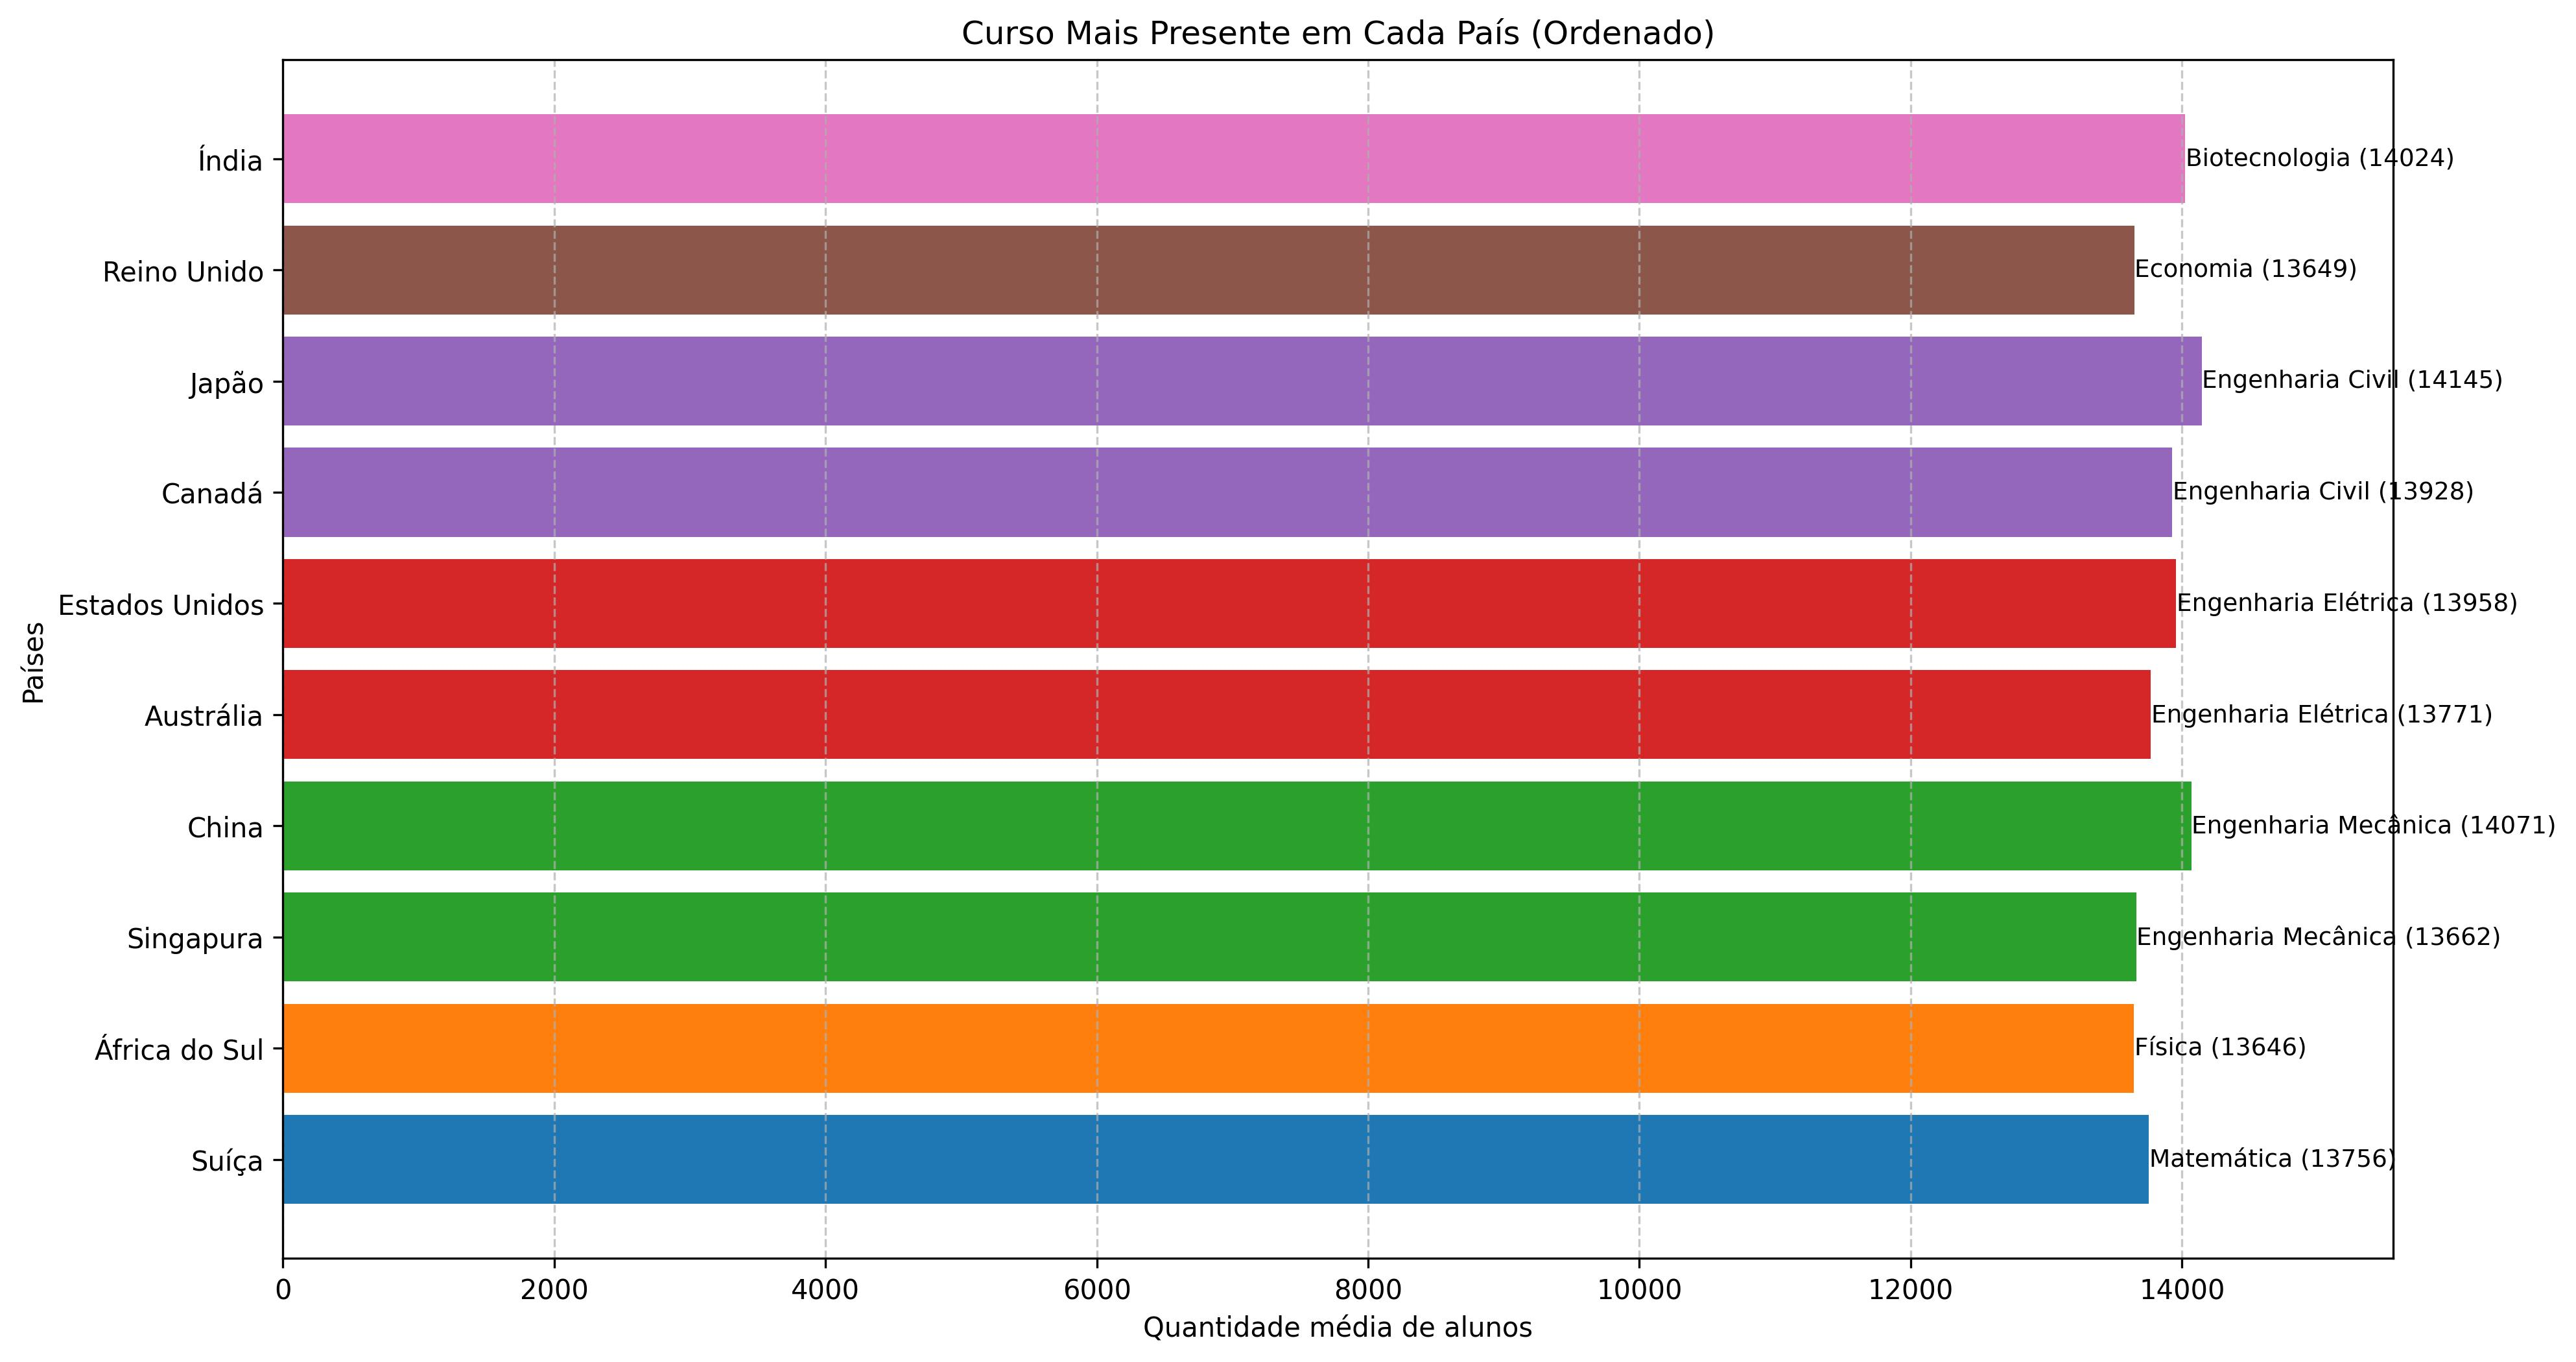

In [45]:
current_dir = os.getcwd()
image_path = os.path.join(current_dir, 'graficos', 'curso-maior-qtd-media-aluno-pais.jpeg')
display(Image(filename=image_path))

## Quais países com melhor CGPA (Cumulative Grade Point Average)?

Os países com maior CGPA médio são Canadá, China e Índia, com uma diferença mínima dos outros países. Entretanto, vale reparar que os países com maior CGPA possuem menos faculdades em seus territórios que os demais, exceto pela China.

In [46]:
display(media_cgpa_pais, qtd_universid_pais)

,Pais,CGPA
1,Canadá,8.73
2,China,8.72
9,Índia,8.72
7,Suíça,8.71
6,Singapura,8.71
5,Reino Unido,8.71
4,Japão,8.70
3,Estados Unidos,8.70
0,Austrália,8.69
8,África do Sul,8.68


,Quantidade de faculdades
Pais,
China,5052
África do Sul,5052
Suíça,5025
Austrália,5018
Singapura,5013
Japão,4991
Estados Unidos,4985
Canadá,4974
Reino Unido,4945


## Quais cursos com maior taxa de empregabilidade?

Os países possuem diferentes cursos com maior taxa de empregabilidade em seus territórios, indicando quais cursos seus mercado de trabalho interno valorizam mais. Entretanto, quando analisamos a média global, os cursos com mais empregabilidade são Biotecnologia, Engenharia Química e Ciência da Computação, mas com uma diferença de décimos dos demais cursos.

In [47]:
display(maior_porcent_empreg_curso_pais,empreg_cursos_global)

Curso,Pais,Curso,Empregabilidade (%)
0,Austrália,Biotecnologia,83.02
1,Canadá,Engenharia Química,83.36
2,China,Economia,83.11
3,Estados Unidos,Economia,83.06
4,Japão,Engenharia Química,83.50
5,Reino Unido,Biotecnologia,83.72
6,Singapura,Matemática,82.87
7,Suíça,Ciência da Computação,83.61
8,África do Sul,Engenharia Civil,82.92
9,Índia,Engenharia Civil,82.94


,Taxa_Formados_Empregados
Curso,
Biotecnologia,82.62
Engenharia Química,82.52
Ciência da Computação,82.50
Engenharia Elétrica,82.34
Engenharia Civil,82.31
Matemática,82.29
Engenharia Mecânica,82.25
Física,82.21
Economia,82.18


## Quais fatores podem influenciar no CGPA de uma faculdade?

A única variável que se correlaciona com CGPA é a renda familiar média anual, possuindo um relacionamento linear positivo com a variável. É uma relação moderada, mas é perceptível que quanto mais alta a renda familiar média de uma faculdade, sua avaliação CGPA tende a ser maior também.

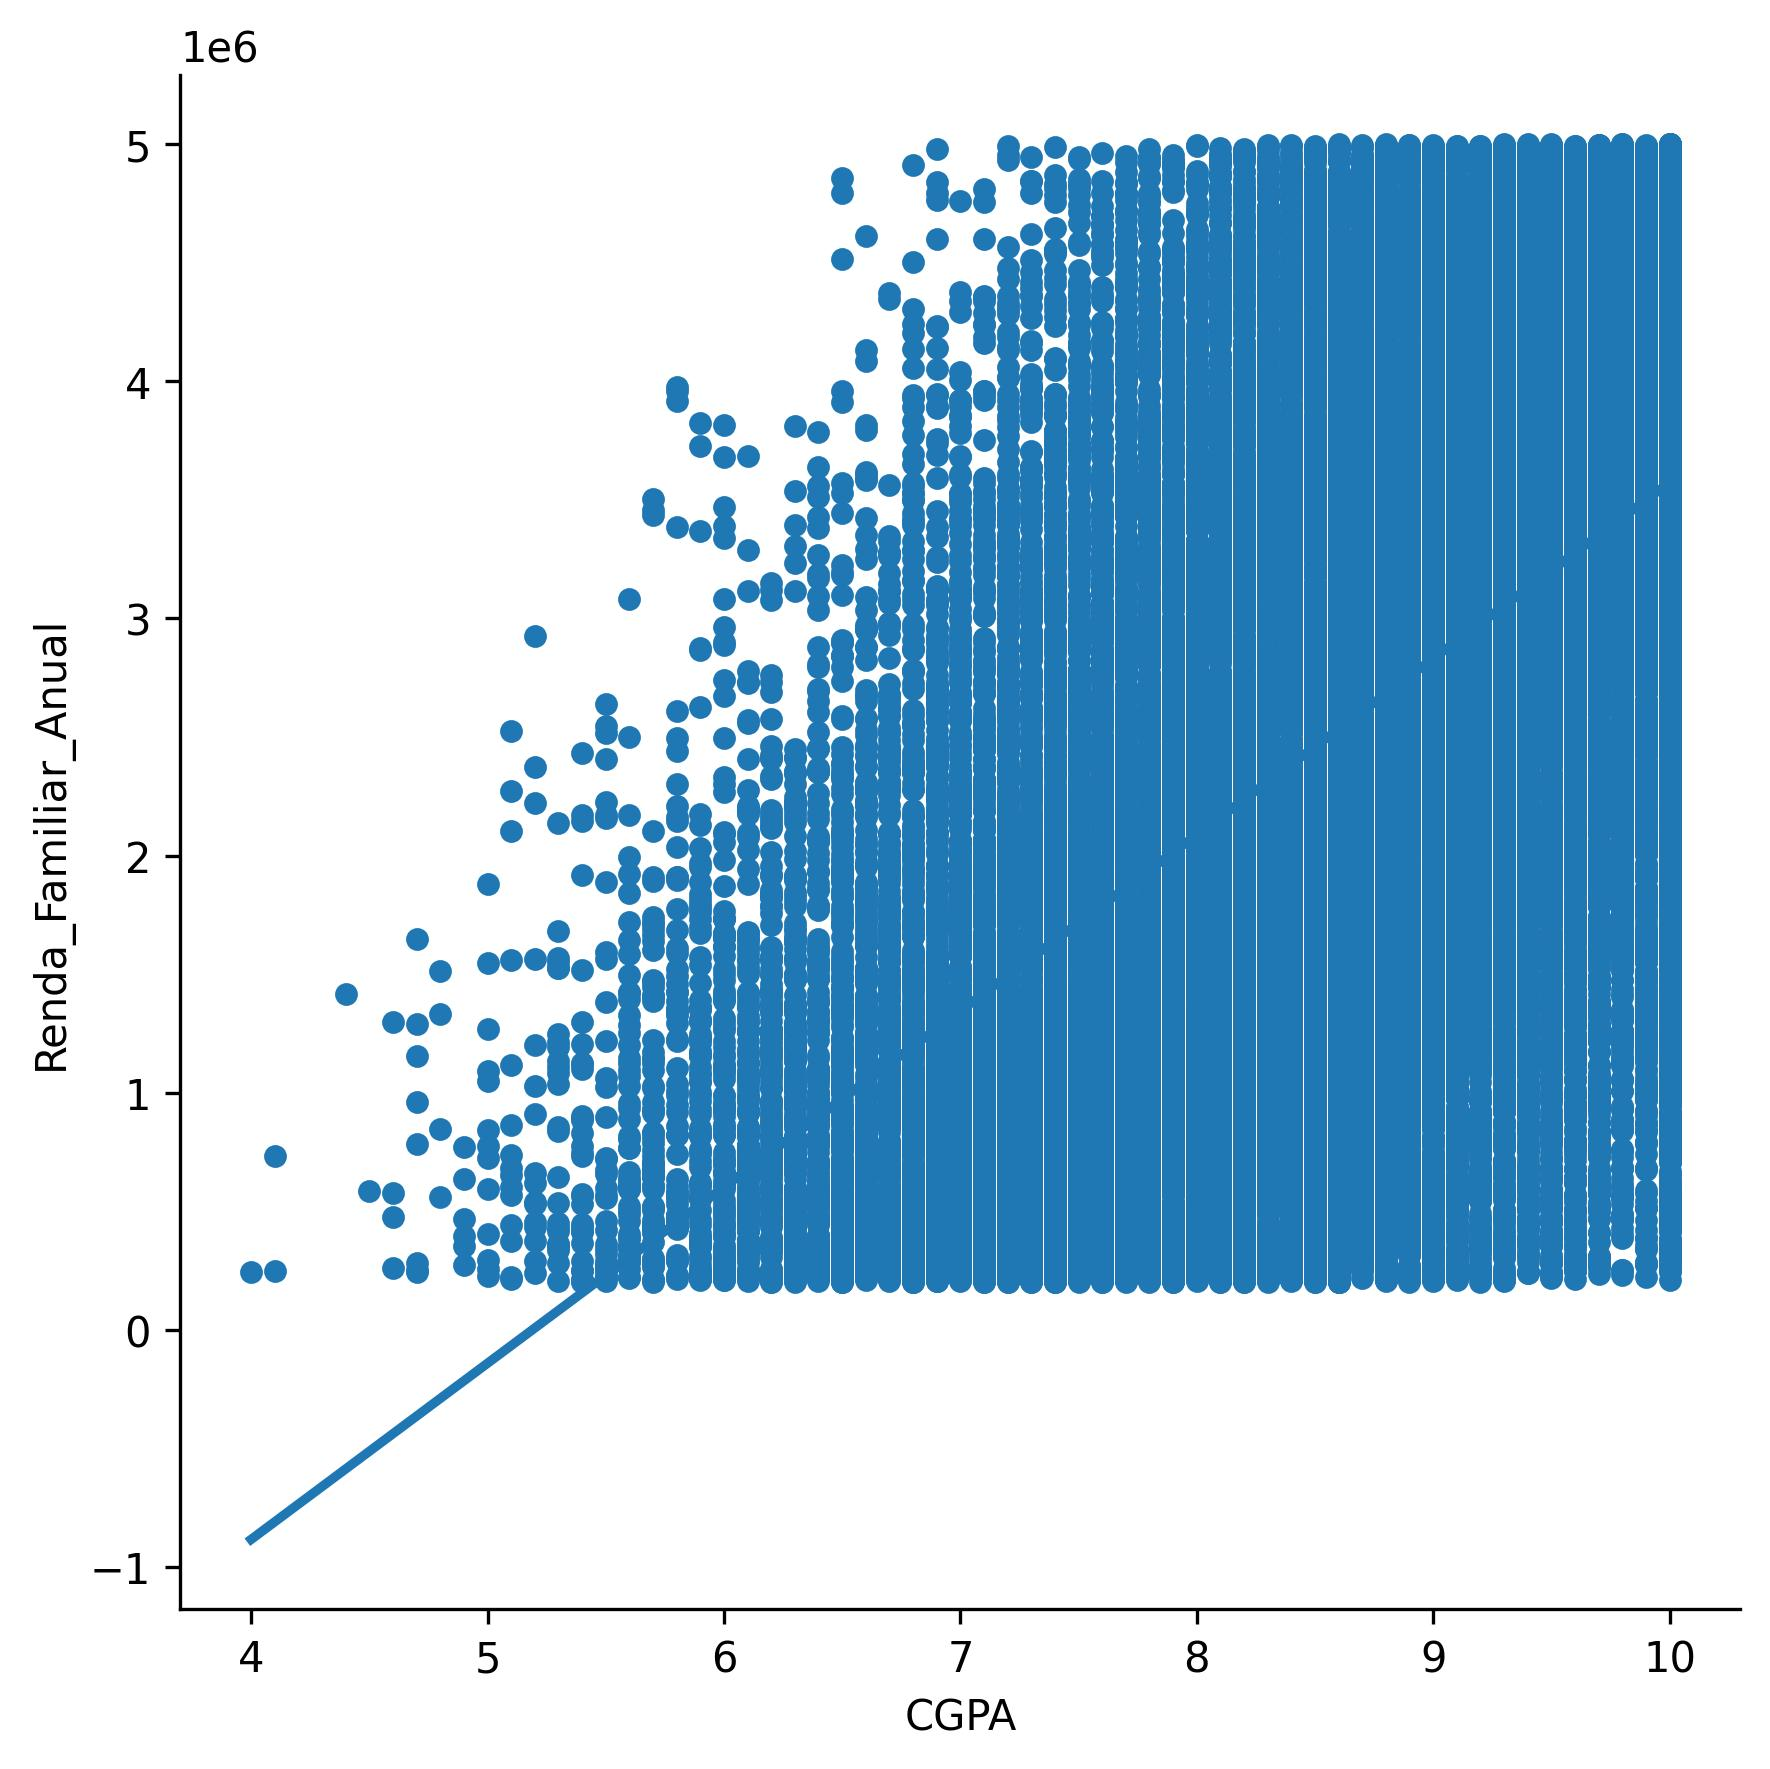

In [48]:
current_dir = os.getcwd()
image_path = os.path.join(current_dir, 'graficos', 'regressao-linaer.jpeg')
display(Image(filename=image_path, width=700))